Epoch 1/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8341 - loss: 0.4001
Epoch 2/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8771 - loss: 0.2989
Epoch 3/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8893 - loss: 0.2756
Epoch 4/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8946 - loss: 0.2610
Epoch 5/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8994 - loss: 0.2519
Epoch 6/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9006 - loss: 0.2462
Epoch 7/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9023 - loss: 0.2409
Epoch 8/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9042 - loss: 0.2383
Epoch 9/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9032 - loss: 0.2356
Epoch 10/10
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9054 - loss: 0.2328
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Accuracy: 0.8087
Precision: 0.8023
Recall: 0.8087
F1-Score: 0.7967

Confusi

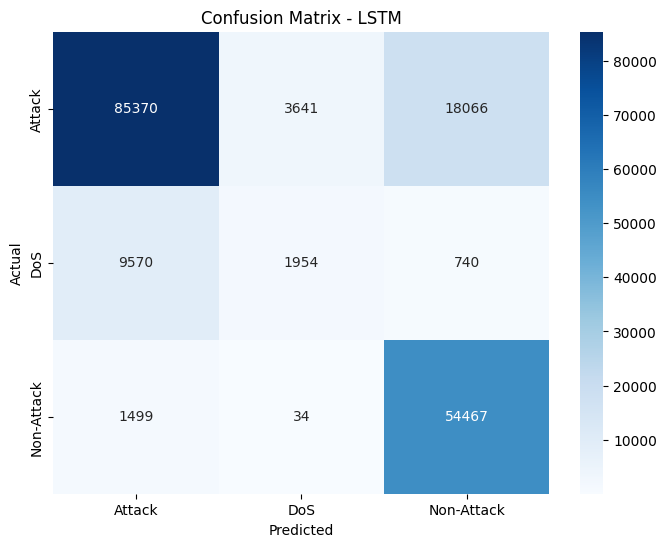

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# تحميل البيانات
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

# الأعمدة غير الضرورية
DROP_COLS = ["id", "attack_cat"]
CAT_COLS = ["proto", "service", "state"]

# تصنيف الهجمات بناءً على `attack_cat`
def preprocess(train_df, test_df):
    train_df_copy = train_df.copy()
    test_df_copy = test_df.copy()

    train_df_copy['label'] = train_df_copy['attack_cat'].apply(
        lambda x: 'DoS' if x == 'DoS' else
        'Non-Attack' if x == 'Normal' else
        'Attack'  # تصنيف باقي الهجمات كـ Attack
    )
    test_df_copy['label'] = test_df_copy['attack_cat'].apply(
        lambda x: 'DoS' if x == 'DoS' else
        'Non-Attack' if x == 'Normal' else
        'Attack'  # تصنيف باقي الهجمات كـ Attack
    )

    train_df_processed = train_df_copy.drop(columns=DROP_COLS, errors="ignore")
    test_df_processed = test_df_copy.drop(columns=DROP_COLS, errors="ignore")

    for col in CAT_COLS:
        le = LabelEncoder()
        combined = pd.concat([train_df_processed[col], test_df_processed[col]]).astype(str)
        le.fit(combined)
        train_df_processed[col] = le.transform(train_df_processed[col].astype(str))
        test_df_processed[col] = le.transform(test_df_processed[col].astype(str))

    train_df_processed = train_df_processed.dropna()
    test_df_processed = test_df_processed.dropna()

    X_train = train_df_processed.drop(columns=["label"]).values
    y_train = train_df_processed["label"].values
    X_test = test_df_processed.drop(columns=["label"]).values
    y_test = test_df_processed["label"].values
    return X_train, y_train, X_test, y_test

# تنفيذ المعالجة المبدئية للبيانات
X_train, y_train, X_test, y_test = preprocess(train_df, test_df)

# Encode string labels to numerical labels for LSTM
label_encoder_y = LabelEncoder()
y_train = label_encoder_y.fit_transform(y_train)
y_test = label_encoder_y.transform(y_test)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for LSTM: [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(units=3, activation='softmax'))  # Output layer for 3 classes (DoS, Non-Attack, Attack)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)  # Convert softmax outputs to class labels

# حساب المقاييس: الدقة، الاسترجاع، F1، المصفوفة الارتباك
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0, average="weighted")
rec = recall_score(y_test, y_pred, zero_division=0, average="weighted")
f1 = f1_score(y_test, y_pred, zero_division=0, average="weighted")
cm = confusion_matrix(y_test, y_pred)

# طباعة النتائج
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# ── رسم المصفوفة الارتباك ───────────────────────────────────
class_names = label_encoder_y.inverse_transform(np.arange(len(label_encoder_y.classes_)))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# حفظ الصورة في ملف
plt.savefig('confusion_matrix_LSTM.png')

# عرض الصورة
plt.show()